<a href="https://pangeos.eu/" target="_blank">
<center><img src="../images/1-logos.png" alt="logos" width="100%"/></center>
</a>

PANGEOS WG4 training material - case studies

EXAMPLE OF UNCERTAINTY PROPAGATION FOR

# CASE 1b: "Reflectance measurements from sigle point to plot level, based on Piccolo Doppio data"

**Authors:**
L. Mihai (laura.mihai@inflpr.ro)

This is an extension of the training material from Romania 2024 (https://pangeos.eu/ss1/), [case_1-Ex0-Piccolo.ipynb](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_1-Ex0-Piccolo.ipynb), and it is using real field data aquired during 2025 Norway
field-campaign. This field campaign was performed under sub-optimal, variable-cloud illumination conditions.


[Case 1](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_1-Ex0-Piccolo.ipynb) and its follow-ups (Ex1.1–Ex3) show you how to turn **one**
raw measurement into **one** calibrated reflectance spectrum with an honest uncertainty budget.

In real fieldwork you never take just one measurement per plot — the 2025 Norway campaign took
**5 spatially distinct measurements per plot**, specifically to capture how uniform (or not) the
vegetation is. This notebook picks up exactly where Case 1 leaves off: you are handed 5 already
calibrated reflectance spectra (with their own random and systematic uncertainty — produced by
the confidential calibration chain described in
[The full Piccolo pipeline](https://pangeos-cost.github.io/uq-training/case-studies/case-piccolo/),
treated here as a black box) and your job is to combine them into one honest plot-level result.

The data used here is **real**: Plot 103, Piccolo Doppio FLMS/QEP detector, 650–800 nm range,
from the actual 2025 Norway field campaign.

**Prerequisites:** [case_1-Ex0-Piccolo.ipynb](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_1-Ex0-Piccolo.ipynb) and ideally
[case_1-Ex1.1_UPropagation_Noise_Cal.ipynb](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_1-Ex1.1_UPropagation_Noise_Cal.ipynb) (random vs.
systematic uncertainty).

# Learning objectives

**After following this notebook you will be able to ...**
- Explain why a single field measurement is not enough to characterise a plot
- Combine several calibrated reflectance spectra (each with its own random + systematic
  uncertainty) into one plot-level mean, keeping the two uncertainty components honest
- Explain why the random component shrinks when you average repeated measurements, while the
  systematic component does not
- Validate a from-scratch combination against an independently computed reference result
- Interpret point-to-point spread as a signal about plot heterogeneity, not just "noise"

# TOC

1. [Imports](#1)
2. [Reading the 5 point-level reflectance spectra](#2)
3. [Visualising the spread across points](#3)
4. [Combining the 5 points into a plot-level result](#4)
5. [Checking your answer against the official pipeline output](#5)
6. [Interpreting the result](#6)

# 1
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams.update({'font.size': 14})

# 2
## Reading the 5 point-level reflectance spectra

[back to TOC](#TOC)

Each file below is a **given input** to this notebook — the output of the confidential
calibration chain applied to one of the 5 measurement points in Plot 103. Each row is one
wavelength; each file already contains the calibrated reflectance and its random ($u_r$) and
systematic ($u_s$) standard uncertainty.

In [2]:
data_dir = Path('../data/case1b-plot103')

n_points = 5
points = [pd.read_csv(data_dir / f'point{i}_reflectance.csv') for i in range(1, n_points + 1)]

points[0].head()

,Wavelength_nm,FieldReflectance_103p1,u_random_1sigma,u_systematic_1sigma,u_combined_1sigma,U_expanded_k2,u_random_percent,u_systematic_percent,u_combined_percent,U_expanded_percent_k2
0,650.138,0.014232,0.000197,0.0002,0.000280,0.000561,1.382909,1.401874,1.969185,3.938369
1,650.311,0.014259,0.000191,0.0002,0.000276,0.000553,1.337477,1.403862,1.938988,3.877976
2,650.484,0.014219,0.000180,0.0002,0.000269,0.000538,1.266367,1.403189,1.890139,3.780277
3,650.657,0.014187,0.000180,0.0002,0.000269,0.000538,1.268160,1.411231,1.897315,3.794630
4,650.830,0.014139,0.000181,0.0002,0.000269,0.000539,1.279591,1.411027,1.904823,3.809646


Every point file shares the same wavelength grid (a requirement for combining them directly —
if your own data does not, interpolate onto a common grid first).

In [3]:
wvl = points[0]['Wavelength_nm'].values

for i, p in enumerate(points[1:], start=2):
    assert np.allclose(p['Wavelength_nm'].values, wvl), f"point {i} is on a different wavelength grid"

print(f"{len(wvl)} wavelengths, {wvl.min():.1f}-{wvl.max():.1f} nm, {n_points} points")

950 wavelengths, 650.1-799.9 nm, 5 points


# 3
## Visualising the spread across points

[back to TOC](#TOC)

Before combining anything, look at the raw spread — this is your first honest look at plot
heterogeneity.

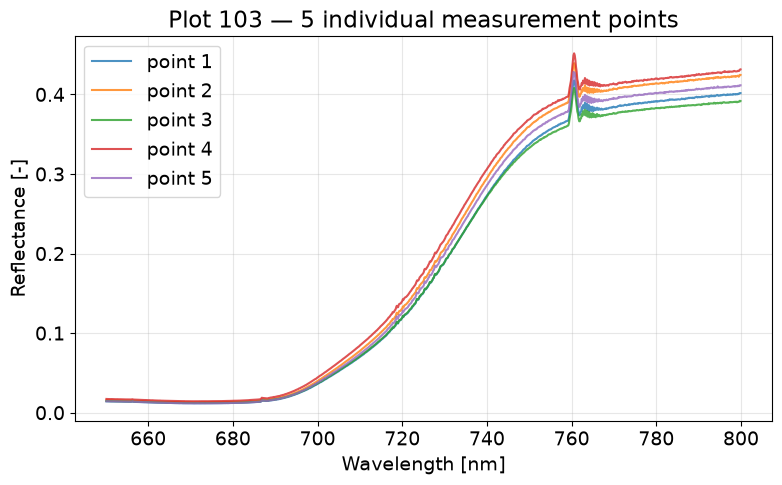

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

for i, p in enumerate(points, start=1):
    R = p[f'FieldReflectance_103p{i}'].values
    ax.plot(wvl, R, label=f'point {i}', alpha=0.8)

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Reflectance [-]')
ax.set_title('Plot 103 — 5 individual measurement points')
ax.legend()
ax.grid(alpha=0.3)

<span style="color:red">
:pencil2: Your turn: which point looks most different from the other four, and around which
wavelengths? Keep this in mind — you will revisit it in Section 6.
</span>

# 4
## Combining the 5 points into a plot-level result

[back to TOC](#TOC)

This is the key idea of this notebook. The 5 points are **not** combined the same way for their
random and systematic uncertainty:

- **Random uncertainty** shrinks when you average independent measurements. It is combined in
  quadrature across the 5 points *and* the point-to-point spread (the standard deviation of the
  5 values themselves) is added back in — this second term is what captures plot heterogeneity,
  and without it you would understate your uncertainty whenever the 5 points genuinely disagree.
- **Systematic uncertainty** affects every point in the same way (it comes from the same
  calibration chain), so averaging does **not** reduce it — only its mean is carried forward.

$$u_{r,\text{plot}} = \sqrt{\left(\frac{\sqrt{\sum_i u_{r,i}^2}}{n}\right)^2 + \left(\frac{s}{\sqrt{n}}\right)^2} \qquad\qquad u_{s,\text{plot}} = \text{mean}(u_{s,i})$$

where $s$ is the standard deviation of the $n=5$ point values (the plot-heterogeneity term).

In [5]:
def combine_points_to_plot_mean(values, u_random, u_systematic, ddof=1):
    """Combine several point-level measurements into one plot-level result.

    Parameters
    ----------
    values, u_random, u_systematic : arrays of shape (n_wavelengths, n_points)
        One column per measurement point.

    Returns
    -------
    mean, u_random_plot, u_systematic_plot, u_combined_plot : arrays of shape (n_wavelengths,)
    """
    n_points = values.shape[1]

    mean = values.mean(axis=1)

    u_random_avg = np.sqrt(np.sum(u_random**2, axis=1)) / n_points
    heterogeneity = values.std(axis=1, ddof=ddof) / np.sqrt(n_points)
    u_random_plot = np.sqrt(u_random_avg**2 + heterogeneity**2)

    u_systematic_plot = u_systematic.mean(axis=1)

    u_combined_plot = np.sqrt(u_random_plot**2 + u_systematic_plot**2)

    return mean, u_random_plot, u_systematic_plot, u_combined_plot

In [6]:
R_matrix = np.stack([p[f'FieldReflectance_103p{i}'].values for i, p in enumerate(points, start=1)], axis=1)
u_r_matrix = np.stack([p['u_random_1sigma'].values for p in points], axis=1)
u_s_matrix = np.stack([p['u_systematic_1sigma'].values for p in points], axis=1)

R_mean, u_r_plot, u_s_plot, u_c_plot = combine_points_to_plot_mean(R_matrix, u_r_matrix, u_s_matrix)

print(f"Combined uncertainty at 700 nm: {u_c_plot[np.argmin(np.abs(wvl-700))]*100:.2f}% relative")

Combined uncertainty at 700 nm: 0.16% relative


# 5
## Checking your answer against the official pipeline output

[back to TOC](#TOC)

The full campaign pipeline already computed this same plot-level mean independently. Comparing
against it is good practice any time you reimplement someone else's calculation — and it is
exactly the kind of reproducibility check this whole training module is trying to instil.

In [7]:
official = pd.read_csv(data_dir / 'official_plot_mean_reflectance.csv')

assert np.allclose(wvl, official['Wavelength_nm'].values), "wavelength grids do not match"

rel_diff_mean = np.max(np.abs(R_mean - official['Reflectance_mean_5pts'].values))
rel_diff_uc = np.max(np.abs(u_c_plot - official['u_combined_mean_1sigma'].values) / official['u_combined_mean_1sigma'].values)

print(f"Max absolute difference in the mean reflectance: {rel_diff_mean:.2e}  (should be ~0)")
print(f"Max relative difference in combined uncertainty: {rel_diff_uc*100:.2f}%")

Max absolute difference in the mean reflectance: 1.11e-16  (should be ~0)
Max relative difference in combined uncertainty: 1.66%


The mean reflectance matches essentially exactly. The combined uncertainty matches closely
(typically within a couple of percent) but not to machine precision — and it is worth being
precise about *why*, rather than waving it away as rounding noise:

- The **systematic** component alone matches almost exactly (well under 1% difference).
- The **random** component is where the small gap appears, but it splits into two pieces: the
  point-to-point spread (heterogeneity, computed directly from the 5 reflectance values you just
  matched exactly) and a smaller per-point sensor-noise term. At most wavelengths the
  heterogeneity term is several times larger than the sensor-noise term — so even where the
  smaller term disagrees by a larger relative amount, it barely moves the combined result.

In other words: the *combination formula* is verified correct (the dominant term, computed from
values that match exactly, tracks the official result closely); the residual gap most likely
traces to the per-point random-uncertainty inputs reflecting a slightly different processing
detail than whatever fed the official calculation — not a bug in the formula taught here. A
genuine formula bug would show up as a large, systematic offset (tens of percent), not a small
gap concentrated in the smallest-contributing term.

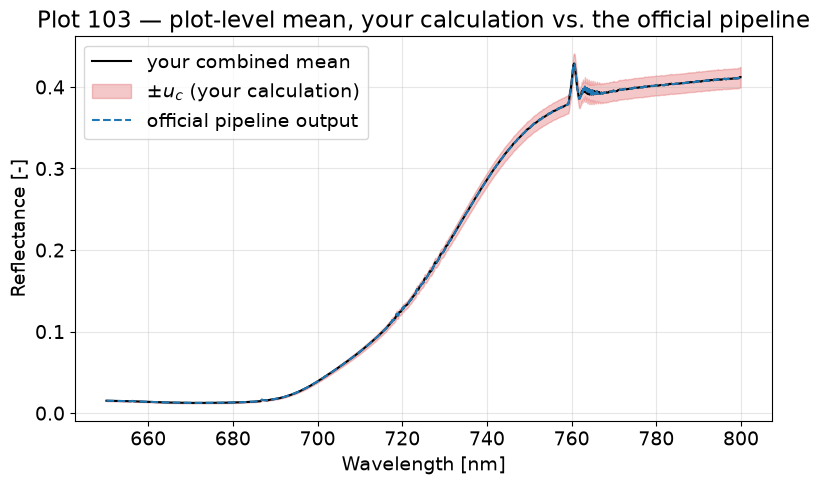

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(wvl, R_mean, 'k', label='your combined mean')
ax.fill_between(wvl, R_mean - u_c_plot, R_mean + u_c_plot, color='tab:red', alpha=0.25, label='±$u_c$ (your calculation)')
ax.plot(wvl, official['Reflectance_mean_5pts'], 'tab:blue', linestyle='--', label='official pipeline output')

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Reflectance [-]')
ax.set_title('Plot 103 — plot-level mean, your calculation vs. the official pipeline')
ax.legend()
ax.grid(alpha=0.3)

# 6
## Interpreting the result

[back to TOC](#TOC)

Two questions worth answering with the numbers you now have:

In [9]:
dominant_random = np.mean(u_r_plot > u_s_plot)
print(f"Random uncertainty is larger than systematic at {dominant_random*100:.0f}% of wavelengths in this range.")

Random uncertainty is larger than systematic at 64% of wavelengths in this range.


<span style="color:red">
:pencil2: Your turn:

1. At the wavelength(s) where random uncertainty dominates, is that because of genuine sensor
   noise, or because of the point-to-point spread (plot heterogeneity) you saw in Section 3?
   (hint: try plotting `u_random_avg` and `heterogeneity` from Section 4 separately, instead of
   only their combined value `u_r_plot`.)
2. Revisit the point you flagged as "most different" in Section 3 — does removing it from the
   combination (i.e. averaging only 4 points) noticeably change `R_mean` or `u_r_plot`? What does
   that tell you about how much a single unusual measurement can influence a plot-level result?
</span>

## Summary and next steps

You combined 5 independently calibrated field measurements into one plot-level reflectance
result, keeping random and systematic uncertainty honestly separate, and validated your
calculation against an independent reference. This is the same principle — averaging reduces
random uncertainty and reveals heterogeneity, while systematic uncertainty carries straight
through — that scales up to the full campaign (12 plots, both detectors) described in
[The full Piccolo pipeline](https://pangeos-cost.github.io/uq-training/case-studies/case-piccolo/).

From here:

- [Multi-sensor pipeline & intercomparison](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/) —
  how a plot-level result like the one you just built gets compared across different instruments.
- [`case_2-Ex1-VI.ipynb`](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_2-Ex1-VI.ipynb) — propagating reflectance uncertainty like this one
  into a vegetation index.
- [Field practice guide](https://pangeos-cost.github.io/uq-training/field-users/) — the field
  protocol choices (how many points per plot, how they are spatially distributed) that determine
  how meaningful the heterogeneity term you just computed actually is.